In [3]:
from CADETProcess.optimization import OptimizationProblem
from CADETProcess.processModel import Inlet, MCT, Outlet, TubularReactor
from CADETProcess.optimization import SLSQP, U_NSGA3, Pathos, Joblib, COBYLA, TrustConstr
from CADETProcess.processModel import ComponentSystem,MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet
from CADETProcess.processModel import Process
from CADETProcess.simulator import Cadet
from scipy.optimize import minimize, least_squares
from scipy.ndimage import convolve1d

import logging
from scipy import interpolate
from IPython import display

from utils import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
df = process_roi_txt_to_excel("Phas_6_M12_Internode_below_leaf.txt", "Phas_6_M12_Internode_below_leaf.xlsx")

In [5]:
xi=list(df.columns)
t=df.index.to_numpy()

data_cor=df[xi].to_numpy(dtype=float)

data_unc=df[xi].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

steps=len(data_cor)

d_xi=[]

for i in range(1,len(xi)):
     d_xi.append(float(xi[i])-float(xi[i-1]))

xi=list(np.array(xi)[[3,5,6,7,8,9,10,11]])


exp_data = data_cor*np.exp(-0.000567*60*t.reshape(len(t),1))



weights = 1 #/ np.mean(exp_data, axis=0)




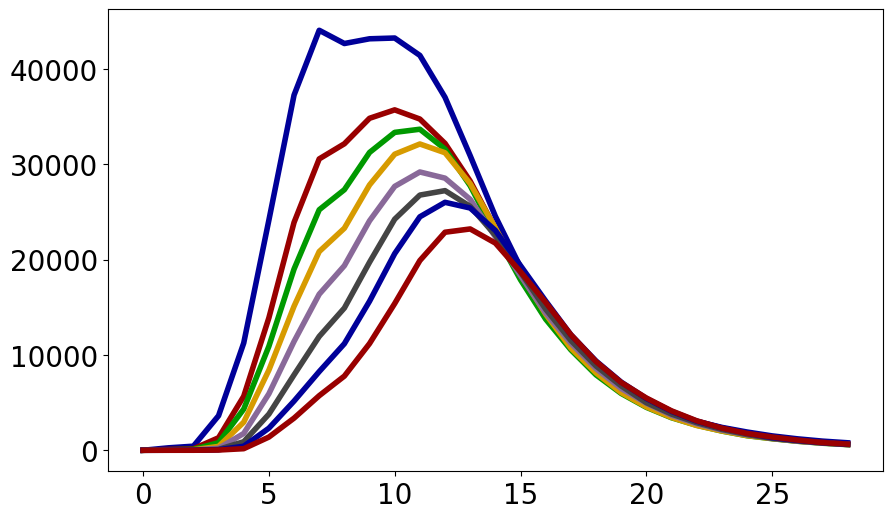

In [6]:

normalized_data = (data_cor[:,[3,5,6,7,8,9,10,11]].T  - data_cor[:,[3,5,6,7,8,9,10,11]].T .min(axis=1, keepdims=True)).T

monotonic_data = normalized_data.copy().T

# Force monotonicity in the first 3 points of each row
for i in range(monotonic_data.shape[0]):
    # Set monotonicity to match the trend from the 4th point
    baseline = monotonic_data[i, 3]*0.1
    monotonic_data[i, :3] = np.linspace(monotonic_data[i, 0], baseline, 3)

plt.plot(monotonic_data.T/np.exp(0.000567*60*t.reshape(len(t),1)))

smooth_exp_data = monotonic_data.T/np.exp(0.000567*60*t.reshape(len(t),1))

exp_data = smooth_exp_data
exp_data = exp_data / np.max(exp_data)

num_new_rows = 1
num_columns = exp_data.shape[1]

new_rows = np.zeros((num_new_rows, num_columns))


exp_data = np.vstack((new_rows, exp_data))
t = np.hstack((t,[145.]))

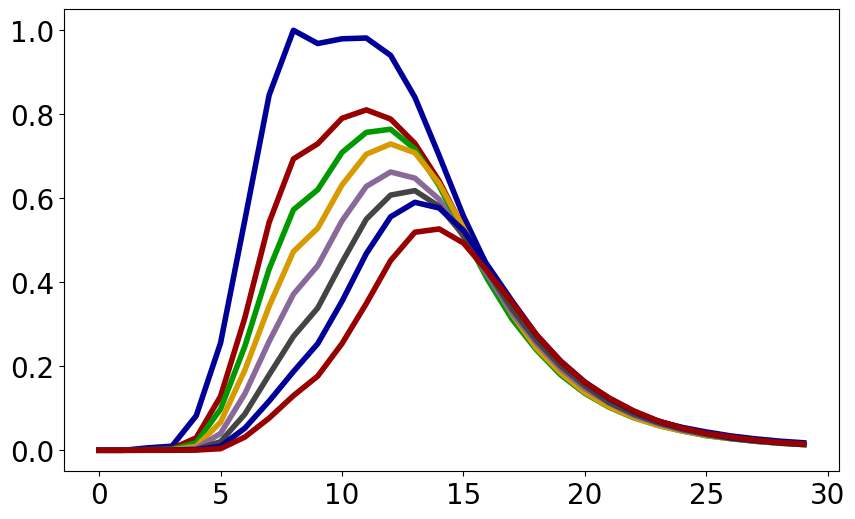

In [7]:
plt.plot(exp_data)

In [8]:
def exponential_kernel(size=200, scale=20.0):
    """
    Continuous exponential kernel for smoothing.

    Parameters:
        size (int): Number of kernel points (support size).
        scale (float): Controls the exponential decay length (continuous).

    Returns:
        np.ndarray: Normalized exponential kernel.
    """
    size = int(size)
    x = np.linspace(-size / 2, size / 2, size)
    kernel = np.exp(-np.abs(x) / scale)
    return kernel / kernel.sum()

# Updated Three-Point Model with Initial Constant Velocity (Using t1, t2, t3)
def velocity_profile(t, p_v0, p_t1, p_t2, p_t3, p_v2, p_v3, smoothing_width=100):
    """
    Generates a velocity profile with an initial constant velocity before change at t1.
    
    Parameters:
        t (numpy.ndarray): Time points to evaluate the velocity profile.
        p_v0 (float): Initial constant velocity.
        p_t1 (float): Duration for which velocity remains constant at p_v0.
        p_t2 (float): Time interval for velocity change.
        p_t3 (float): Time interval for recovery.
        p_v2 (float): Velocity at t2 (after change).
        p_v3 (float): Velocity at t3 (after recovery).
        smoothing_width (int): Width of the exponential kernel for smoothing.
    
    Returns:
        numpy.ndarray: Smoothed velocity profile.
    """
    time_points = [0, p_t1, p_t2, p_t3]  # Ensure an initial constant phase
    velocities = [p_v0, p_v0, p_v2, p_v3]  # Hold velocity constant before change

    profile = np.interp(t, time_points, velocities)

    kernel = exponential_kernel(smoothing_width, scale=smoothing_width)
    smoothed_profile = convolve1d(profile, kernel, mode="nearest")

    return smoothed_profile



In [9]:
def setup_process(x):
    
    p_volumetric_flow_rate_const_t0 = x[0]
    p_mct1_e12 = x[1]
    p_total_porosity = x[2]
    p_col_dispersion = x[3]
    p_x0 = x[4]
    p_dt1= x[5]
    p_dt2= x[6]
    p_dt3= x[7]
    p_v2= x[8] 
    p_v3= x[9]
    p_t0 =x[10]
    p_mct_disp=x[11]

        
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    tube = TubularReactor(component_system, name='stem')
    mct1 = MCT(component_system, nchannel=2, name='mct1')
    outlet = Outlet(component_system, name='outlet')

    leaf.discretization.ncol = 20
    mct1.discretization.ncol = 30


    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)

    mct1.bulk_reaction_model = reaction_system


    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(tube)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(outlet)
    
    tube.length = p_x0
    tube.axial_dispersion = 0
    tube.diameter = np.sqrt(1/np.pi)

    leaf.total_porosity = p_total_porosity
    leaf.length =  0.01
    leaf.diameter = np.sqrt(1/np.pi)*17
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, tube)
    mct_flow_sheet.add_connection(tube, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, outlet, origin_port = 'channel_0')
 
    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi[-1]/1000
    
    mct1.channel_cross_section_areas = [1,1] 
    
    mct1.axial_dispersion = p_mct_disp
    
    mct1.solution_recorder.write_solution_bulk = 1

    mct1.exchange_matrix = np.array([
                                    [[0.0], [p_mct1_e12]],
                                    [[0.0], [0.0]],
                                    ])
                                


    process.cycle_time = 60*t[-1]
    
    _ = process.add_event('Base', 'flow_sheet.inlet.c', [1],0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [1],p_t0*60+0.1)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0],p_t0*60+6*60)
    
    
    t_curve = np.linspace(0, t[-1] * 60, len(t)*5)
  
    
    p_t1 = p_dt1
    p_t2 = p_dt2
    p_t3 = p_dt3
    
  
    curve_modified =velocity_profile(t_curve, p_v0=p_volumetric_flow_rate_const_t0, p_t1=p_t1 * 60, p_t2=p_t2 * 60, p_t3=p_t3 * 60, 
                                    p_v2=p_v2, p_v3=p_v3, smoothing_width=1)

    process.add_flow_rate_profile(inlet, t_curve, curve_modified)
    
    #plt.plot(t_curve, curve_modified, label="Smoothed Profile")
    #_ = process.plot_events()    

        
    return process

In [10]:
xi[2]/1000-xi[0]/1000+xi[-1]/1000-xi[2]/1000

np.float64(0.08986540519894881)

In [11]:
# Define min and max values for each parameter
param_bounds = {
    'volumetric_flow_rate_const': (1e-05, 3e-04),  # log-scaling, volumetric_flow_rate_const
    'mct1_e12': (1.53039589e-5, 6.12158354e-03),  # log-scaling, mct1_e12
    'total_porosity': (0.1, 0.99),          # linear scaling, total_porosity
    'col_dispersion': (2.83319089e-12, 1.13327635e-04),  # log-scaling, col_dispersion
    'x0': (0.0001, 0.01),           # linear scaling, t0
    'p_t1' : (0,35),
    'p_t2' : (35,55),
    'p_t3' : (55,120),
    'p_v2' : (1e-05, 8e-05),
    'p_v3' : (1e-05, 2e-04),
    'p_t0': (0,10),
    'mct_dispersion': (2.83319089e-12, 1.13327635e-06)}


    
def normalize_parameters(x):
    normalized_x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # If the range is large, use log scaling
            norm_param = (np.log(x[i]) - np.log(min_val)) / (np.log(max_val) - np.log(min_val))
        else:  # For compact ranges, use min-max scaling
            norm_param = (x[i] - min_val) / (max_val - min_val)
        
        normalized_x.append(norm_param)
    
    return np.array(normalized_x)

def denormalize_parameters(norm_x):
    x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # Log scaling for large ranges
            param_value = np.exp(norm_x[i] * (np.log(max_val) - np.log(min_val)) + np.log(min_val))
        else:  # Min-max scaling for compact ranges
            param_value = norm_x[i] * (max_val - min_val) + min_val
        
        x.append(param_value)
    
    return np.array(x)

def analyze_parameters(norm_param_values, param_bounds=param_bounds):
    """
    Analyze parameters and print their names, denormalized values, and normalized values.

    Args:
        norm_param_values (list): Normalized parameter values (0-1 range).
        param_bounds (dict): Dictionary with parameter names as keys and boundary tuples as values.

    Returns:
        None: Prints the analysis.
    """
    print(f"{'Name':<30}{'Denormalized Value':<20}{'Normalized Value':<10}")
    print("-" * 65)

    # Denormalize parameters
    param_values = denormalize_parameters(norm_param_values)

    for i, (name, bounds) in enumerate(param_bounds.items()):
        value = param_values[i]
        norm_param = norm_param_values[i]

        print(f"{name:<30}{value:<20.8e}{norm_param:<10.2f}")

In [12]:
def mct_obj_norm(x_norm):

    x = denormalize_parameters(x_norm)
    
    print(np.array(x_norm))
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[3]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = list(np.array(lenghts[:]))

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
   

    calc_data = calc_data_mct1 # np.hstack((calc_data_mct1,calc_data_mct2))
    calc_data = calc_data/np.max(calc_data)
    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    
    plot_fit(time_new, calc_data, exp_data)
    print(np.array(x_norm))

    return SSQ

In [13]:
def mct_obj_res(x_norm):

    x = denormalize_parameters(x_norm)

    process = setup_process(x)

    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[3]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = list(np.array(lenghts[:]))

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()


    calc_data = calc_data_mct1 # np.hstack((calc_data_mct1,calc_data_mct2))
    calc_data = calc_data/np.max(calc_data)

    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    plot_fit(time_new, calc_data, exp_data)

    return weighted_residuals

In [14]:
def plot_fit(time, calc_data, experimental_data):

    display.clear_output(wait=True)
    
    res=np.sum(((calc_data.ravel()-exp_data.ravel())**2).reshape(30,8),axis=1)
    

    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(121)
    ax1.plot(time/60,calc_data[:], label="mct1", color='k', linewidth=1)
    ax1.plot(time/60,res, label="res", color='b')
    ax1.plot(time/60,experimental_data,'.')
    
    #ax1.legend()

    # ax2 = fig.add_subplot(132)

    # ax3 = fig.add_subplot(133)
    # ax3.plot(self.ssq_list, label=ssq)
    # v_text='v:'+str(v)
    # ax3.set_title(v_text)
    # ax3.legend()

    display.display(fig)
    plt.close(fig)

In [15]:
simulator = Cadet()    
simulator.time_resolution = 60
simulator.use_dll = True

In [14]:

x = denormalize_parameters([0.47104146, 0.32543037, 0.33357796, 0.4026239 , 0.00423363,
       0.56323247, 0.28316191, 0.22903893, 0.68986341, 0.59769985,
       0.7548011 , 0.00943101])

process = setup_process(x)

simulation_results = simulator.simulate(process) 

In [15]:
analyze_parameters([0.47104146, 0.32543037, 0.33357796, 0.4026239 , 0.00423363,
       0.56323247, 0.28316191, 0.22903893, 0.68986341, 0.59769985,
       0.7548011 , 0.00943101])

Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
volumetric_flow_rate_const    1.46602023e-04      0.47      
mct1_e12                      1.07545721e-04      0.33      
total_porosity                3.96884384e-01      0.33      
col_dispersion                3.25871874e-09      0.40      
x0                            1.41912937e-04      0.00      
p_t1                          1.97131365e+01      0.56      
p_t2                          4.06632382e+01      0.28      
p_t3                          6.98875304e+01      0.23      
p_v2                          5.82904387e-05      0.69      
p_v3                          1.23562972e-04      0.60      
p_t0                          7.54801100e+00      0.75      
mct_dispersion                3.19969749e-12      0.01      


In [16]:
denormalize_parameters([0.49255458, 0.32117407, 0.42393382, 0.36623244, 0.10630153,
       0.63599474, 0.53711068, 0.25746537, 0.70980943, 0.54453701,
       0.43495777, 0.07997385])

array([1.52840828e-04, 1.04837822e-04, 4.77301100e-01, 1.72344257e-09,
       1.15238515e-03, 2.22598159e+01, 4.57422136e+01, 7.17352490e+01,
       5.96866601e-05, 1.13462032e-04, 4.34957770e+00, 7.94866405e-12])

In [17]:
normalize_parameters([1.52840828e-04, 1.04837822e-04, 4.77301100e-01, 1.72344257e-09,
       1.15238515e-03, 2.22598159e+01, 4.57422136e+01, 7.17352490e+01,
       5.96866601e-05, 1.13462032e-04, 4.34957770e+00, 7.94866405e-10])

array([0.49255458, 0.32117407, 0.42393382, 0.36623244, 0.10630153,
       0.63599474, 0.53711068, 0.25746537, 0.70980943, 0.54453701,
       0.43495777, 0.43698538])

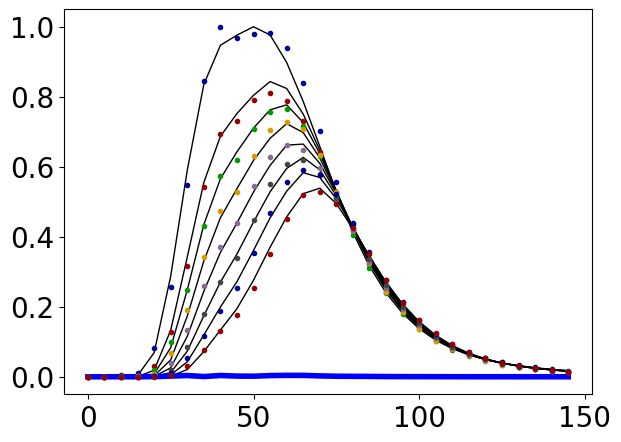

[0.47104146 0.32543037 0.33357796 0.4026239  0.00423363 0.56323247
 0.28316191 0.22903893 0.68986341 0.59769985 0.7548011  0.00943101]


np.float64(0.03387471117600031)

In [18]:
mct_obj_norm([0.47104146, 0.32543037, 0.33357796, 0.4026239 , 0.00423363,
       0.56323247, 0.28316191, 0.22903893, 0.68986341, 0.59769985,
       0.7548011 , 0.00943101])

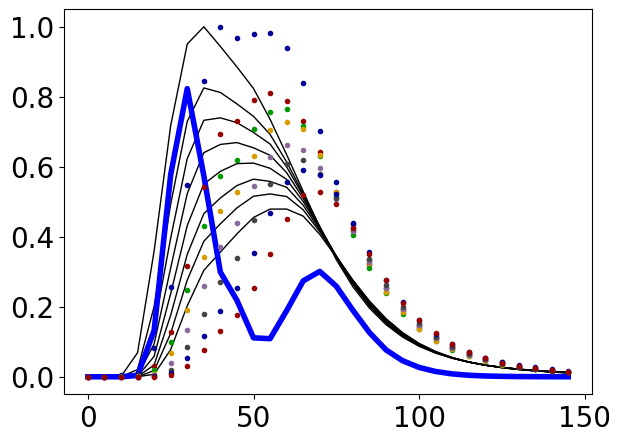

[0.63161084 0.32948736 0.32365017 0.42552228 0.01       0.46263378
 0.10304332 0.20439895 0.69517109 0.68269671 0.77327769 0.01      ]
[0.66319138 0.32948736 0.32365017 0.42552228 0.01       0.46263378
 0.10304332 0.20439895 0.69517109 0.68269671 0.77327769 0.01      ]


KeyboardInterrupt: 

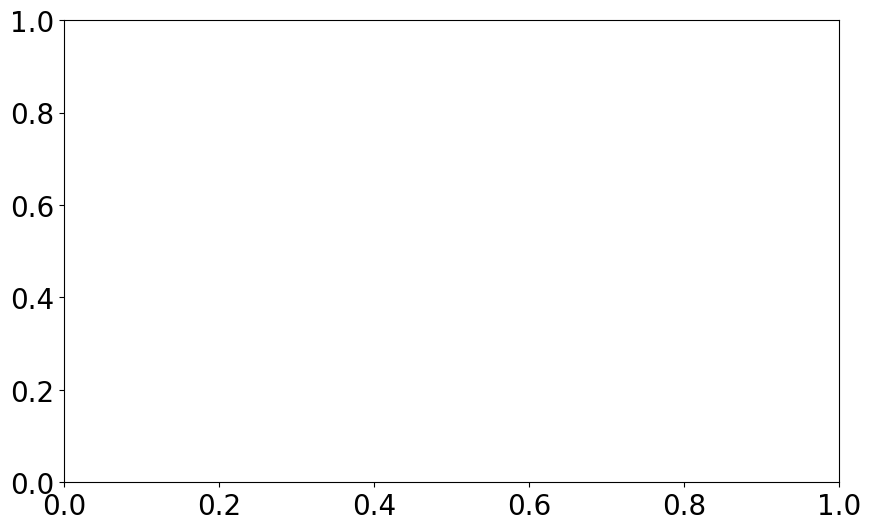

In [20]:
x0 = np.array([0.63161084, 0.32948736, 0.32365017 ,0.42552228 ,0.01, 0.46263378 ,0.10304332,
 0.20439895 ,0.69517109, 0.68269671, 0.77327769,0.01])

# Initialize the plot
fig, ax = plt.subplots()

weights = 1 / np.max(exp_data, axis=0)

fig.canvas.draw()
display.display(fig)

result_nm= minimize(
    fun=mct_obj_norm,
    x0=x0,
    method='Nelder-Mead',
     bounds= (12*((0,1),)),
       options = {
       'disp': True,
       'maxfun': 2000
       })

In [ ]:
result_nm.x

NameError: name 'result_nm' is not defined

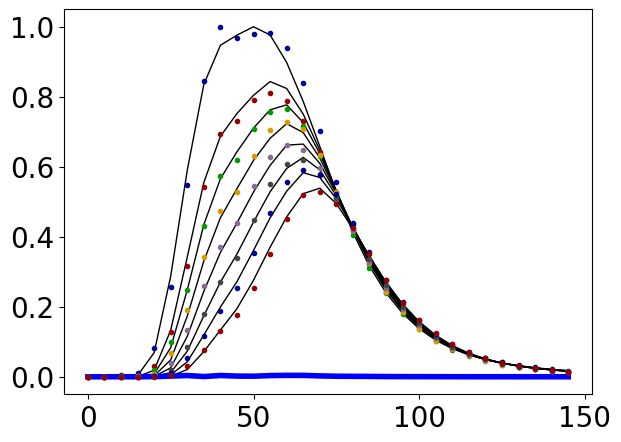

[0.47104146 0.32543037 0.33357796 0.4026239  0.00423363 0.56323247
 0.28316191 0.22903893 0.68986341 0.59769985 0.7548011  0.00943706]


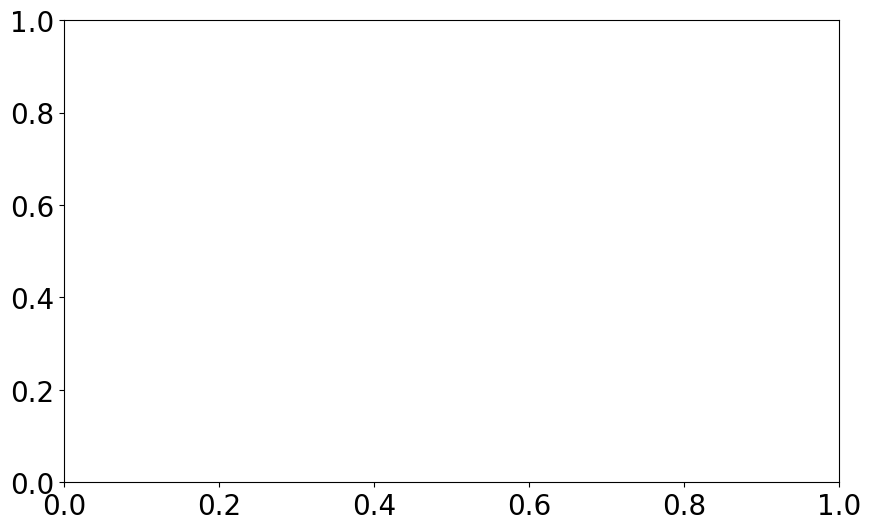

In [21]:
x0 = np.array([0.47104086, 0.32543117 ,0.33357887 ,0.40262367 ,0.00423368, 0.56323251,
 0.28316046 ,0.22903849, 0.68986375 ,0.59769955, 0.75480009 ,0.00943101])

# Initialize the plot
fig, ax = plt.subplots()

weights = 1 / np.max(exp_data, axis=0)

fig.canvas.draw()
display.display(fig)

result_nm= minimize(
    fun=mct_obj_norm,
    x0=x0,
    method='L-BFGS-B',
    jac = '3-point',
     bounds= (12*((0,1),)),
       options = {
       'disp': True,
       })

In [23]:
result_nm.x

array([0.47104146, 0.32543037, 0.33357796, 0.4026239 , 0.00423363,
       0.56323247, 0.28316191, 0.22903893, 0.68986341, 0.59769985,
       0.7548011 , 0.00943101])

In [ ]:
t

array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
       110., 115., 120., 125., 130., 135., 140., 145., 150.])

In [19]:
def plot_pretty(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    plt.style.use('default')
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+60,60)

    mct1 = process.flow_sheet.units[3]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = list(np.array(lenghts[:]))

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
   

    calc_data = calc_data_mct1 # np.hstack((calc_data_mct1,calc_data_mct2))
    calc_data = calc_data/np.max(calc_data)
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14) 
    
    t_plot = [-5, 0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
       110., 115., 120., 125., 130., 135., 140.]

    time_new_plot = np.arange(-5,140+1,1)


    plt.plot(time_new_plot[10:],calc_data[10:], label="Simulated Data", linewidth=1.5)
    plt.gca().set_prop_cycle(None)
    plt.plot(t_plot[4:],exp_data[4:], '.',  markersize=8,label="Experimental Data",)
    
    plt.xlabel("Time [min]")
    plt.ylabel("Activity [a.u.]")
    
    
    # Remove duplicate labels while keeping the first occurrence
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_labels = {}
    unique_handles = []

    for handle, label in zip(handles, labels):
        if label not in unique_labels:  # Keep first occurrence
            unique_labels[label] = handle
            unique_handles.append(handle)

    # Add legend with unique labels
    plt.legend(unique_handles, unique_labels.keys(), fontsize=12)
    
    plt.xlabel("Time [min]", fontsize=15)
    plt.ylabel("Activity [a.u.]", fontsize=15)
    plt.savefig("M12_global.pdf", format="pdf")  
    

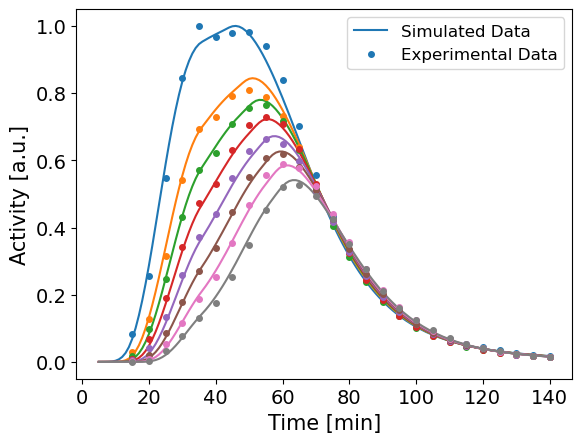

In [20]:
plot_pretty([0.47104086, 0.32543117 ,0.33357887 ,0.40262367 ,0.00423368, 0.56323251,
 0.28316046 ,0.22903849, 0.68986375 ,0.59769955, 0.75480009 ,0.00943101])

In [ ]:
Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
volumetric_flow_rate_const    1.46602023e-04      0.47      
mct1_e12                      1.07545721e-04      0.33      
total_porosity                3.96884384e-01      0.33      
col_dispersion                3.25871874e-09      0.40      
x0                            1.41912937e-04      0.00      
p_t1                          1.97131365e+01      0.56      
p_t2                          4.06632382e+01      0.28      
p_t3                          6.98875304e+01      0.23      
p_v2                          5.82904387e-05      0.69      
p_v3                          1.23562972e-04      0.60      
p_t0                          7.54801100e+00      0.75      
mct_dispersion                3.19969749e-12      0.01      

Parameter 0: ±6.6676589748871935%
Parameter 1: ±4.2475023973984065%
Parameter 2: ±3.785152829871521%
Parameter 3: ±1.8578528905720444%
Parameter 4: ±67892.23302031663%
Parameter 5: ±15.553313760676854%
Parameter 6: ±10.227817543478968%
Parameter 7: ±12.31026985697255%
Parameter 8: ±2.263343341727362%
Parameter 9: ±4.879409521616604%
Parameter 10: ±830538.2914869549%
Parameter 11: ±2681750.1520828316%

SyntaxError: invalid syntax (3234014970.py, line 1)

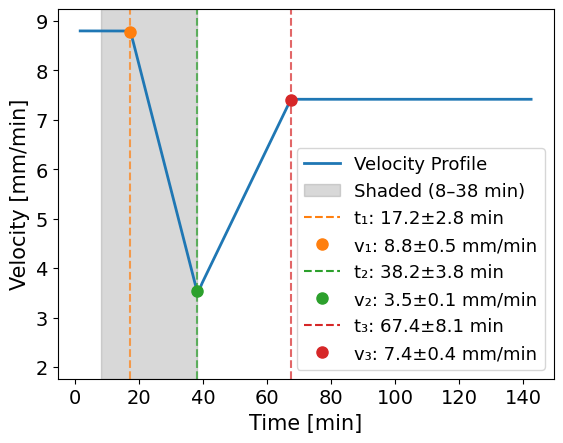

In [21]:
# Example parameters (Replace these with actual values)
p_v0 = 1.46602023e-04
p_t1 =  1.97131365e+01
p_t2 =   4.06632382e+01 
p_t3 =   6.98875304e+01
p_v2 =   5.82904387e-05 
p_v3 =1.23562972e-04

# Define time array and parameters
t_plot = np.linspace(0, 145 * 60, len(t)*60)  # Ensure `t` is defined

final_process = setup_process(denormalize_parameters([0.47104086, 0.32543117 ,0.33357887 ,0.40262367 ,0.00423368, 0.56323251,
 0.28316046 ,0.22903849, 0.68986375 ,0.59769955, 0.75480009 ,0.00943101]))
smoothed_interpolated = final_process.parameter_timelines['flow_sheet.inlet.flow_rate'].value(t_plot) * (1/1.66667e-5)

plt.style.use('default')

key_times_min =[p_t1-5+2.5, p_t2-5+2.5, p_t3-5+2.5]
velocities = np.array([p_v0, p_v2, p_v3]) * (1/1.66667e-5)
uncertainties_time=[0.16, 0.10, 0.12]
uncertainties_velocity=[0.06,0.02,0.05]

import matplotlib.lines as mlines

# Plot velocity profile
t_plot = np.linspace(-5+2.5, 140+2.5, len(t)*60)
plt.plot(t_plot[50:], smoothed_interpolated[50:], label="Velocity Profile", linewidth=2)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Y-axis padding for annotations
plt.ylim(top=np.max(smoothed_interpolated) * 1.05)
plt.ylim(bottom=np.min(smoothed_interpolated) * 0.5)

# Add shaded shadow period
plt.axvspan(8, 38, color='gray', alpha=0.3, label="Shaded (8–38 min)")

# Store custom legend handles
custom_handles = []

def to_subscript(number):
    subscript_digits = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    return str(number).translate(subscript_digits)


# Mark key transition points
for idx, key_time in enumerate(key_times_min):
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][idx+1]

    # Values
    nearest_index = np.abs(t_plot - key_time).argmin()
    y_value = smoothed_interpolated[nearest_index]
    velocity = velocities[idx]
    velocity_unc = velocity * uncertainties_velocity[idx]
    time_unc = key_time * uncertainties_time[idx]

    # Draw vertical line
    plt.axvline(x=key_time, linestyle='--', color=color, alpha=0.7)

    # Draw dot
    plt.plot(key_time, y_value, 'o', color=color, markersize=8)
    
    sub = to_subscript(idx + 1)
    
    time_label = f't{sub}: {key_time:.1f}±{time_unc:.1f} min'
    line_handle = mlines.Line2D([], [], linestyle='--', color=color, label=time_label)

    velocity_label = f'v{sub}: {velocity:.1f}±{velocity_unc:.1f} mm/min'
    dot_handle = mlines.Line2D([], [], color=color, marker='o', linestyle='None', markersize=8, label=velocity_label)
    
    custom_handles.append(line_handle)
    custom_handles.append(dot_handle)
    

    
# Labels and final legend
plt.xlabel("Time [min]", fontsize=15)
plt.ylabel("Velocity [mm/min]", fontsize=15)

# Include default entries (velocity profile & shadow period) + custom handles
default_handles, default_labels = plt.gca().get_legend_handles_labels()
plt.legend(default_handles + custom_handles, default_labels + [h.get_label() for h in custom_handles], fontsize=13, loc='lower right')
plt.savefig("M12_global_v.pdf", format="pdf")  
plt.show()





In [2]:
x_best_fit = [0.47104086, 0.32543117 ,0.33357887 ,0.40262367 ,0.00423368, 0.56323251,
 0.28316046 ,0.22903849, 0.68986375 ,0.59769955, 0.75480009 ,0.00943101]



def compute_jacobian(f, x, eps=None):
    """Computes numerical Jacobian using central difference with adaptive epsilon."""
    x = np.asarray(x)
    n_params = len(x)
    f_x = np.asarray(f(x)).ravel()
    n_outputs = len(f_x)
    J = np.zeros((n_outputs, n_params))

    if eps is None:
        eps = np.sqrt(np.finfo(float).eps) * np.maximum(1.0, np.abs(x))

    for i in range(n_params):
        x_step = np.zeros_like(x)
        x_step[i] = eps[i]

        f_plus = np.asarray(f(x + x_step)).ravel()
        f_minus = np.asarray(f(x - x_step)).ravel()

        J[:, i] = (f_plus - f_minus) / (2 * eps[i])

    return J



# Compute the Jacobian
J = compute_jacobian(mct_obj_res, x_best_fit)

# Step 3: Compute the covariance matrix
JTJ_inv = np.linalg.inv(J.T @ J)  # (J^T J)^-1
sigma_squared = np.var(mct_obj_res(x_best_fit))  # Estimate variance of residuals
C = JTJ_inv * sigma_squared  # Covariance matrix

# Step 4: Compute parameter uncertainties
param_uncertainties = np.sqrt(np.abs(np.diag(C)))  # Extract uncertainties
rel_param_uncertanties = param_uncertainties / np.abs(x_best_fit)

# Print results
for i, uncertainty in enumerate(rel_param_uncertanties):
    print(f"Parameter {i}: ±{uncertainty*100}%")

NameError: name 'mct_obj_res' is not defined